In [1]:
PATH_WORK_DIR = ".."

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
os.chdir(PATH_WORK_DIR)
print(f"DIRECTORY: {os.getcwd()}")

DIRECTORY: c:\Users\jayar\Desktop\바탕 화면\REPO\PROJECT\M1-PJT_DL


In [4]:
import sys
sys.path.append("src")

# Packages

In [5]:
from pathlib import Path
from collections import defaultdict
import pandas as pd
import analysis

# CTR Distribution

In [6]:
PATH = "./result/metric"
path = Path(PATH)
files = list(path.iterdir())

dfs = {
    file.stem: pd.read_csv(file)
    for file in files
}

thresholds = defaultdict(dict)

for key, val in dfs.items():
    model, dim = key.split("_")
    thresholds[model][int(dim)] = val["threshold"].item()

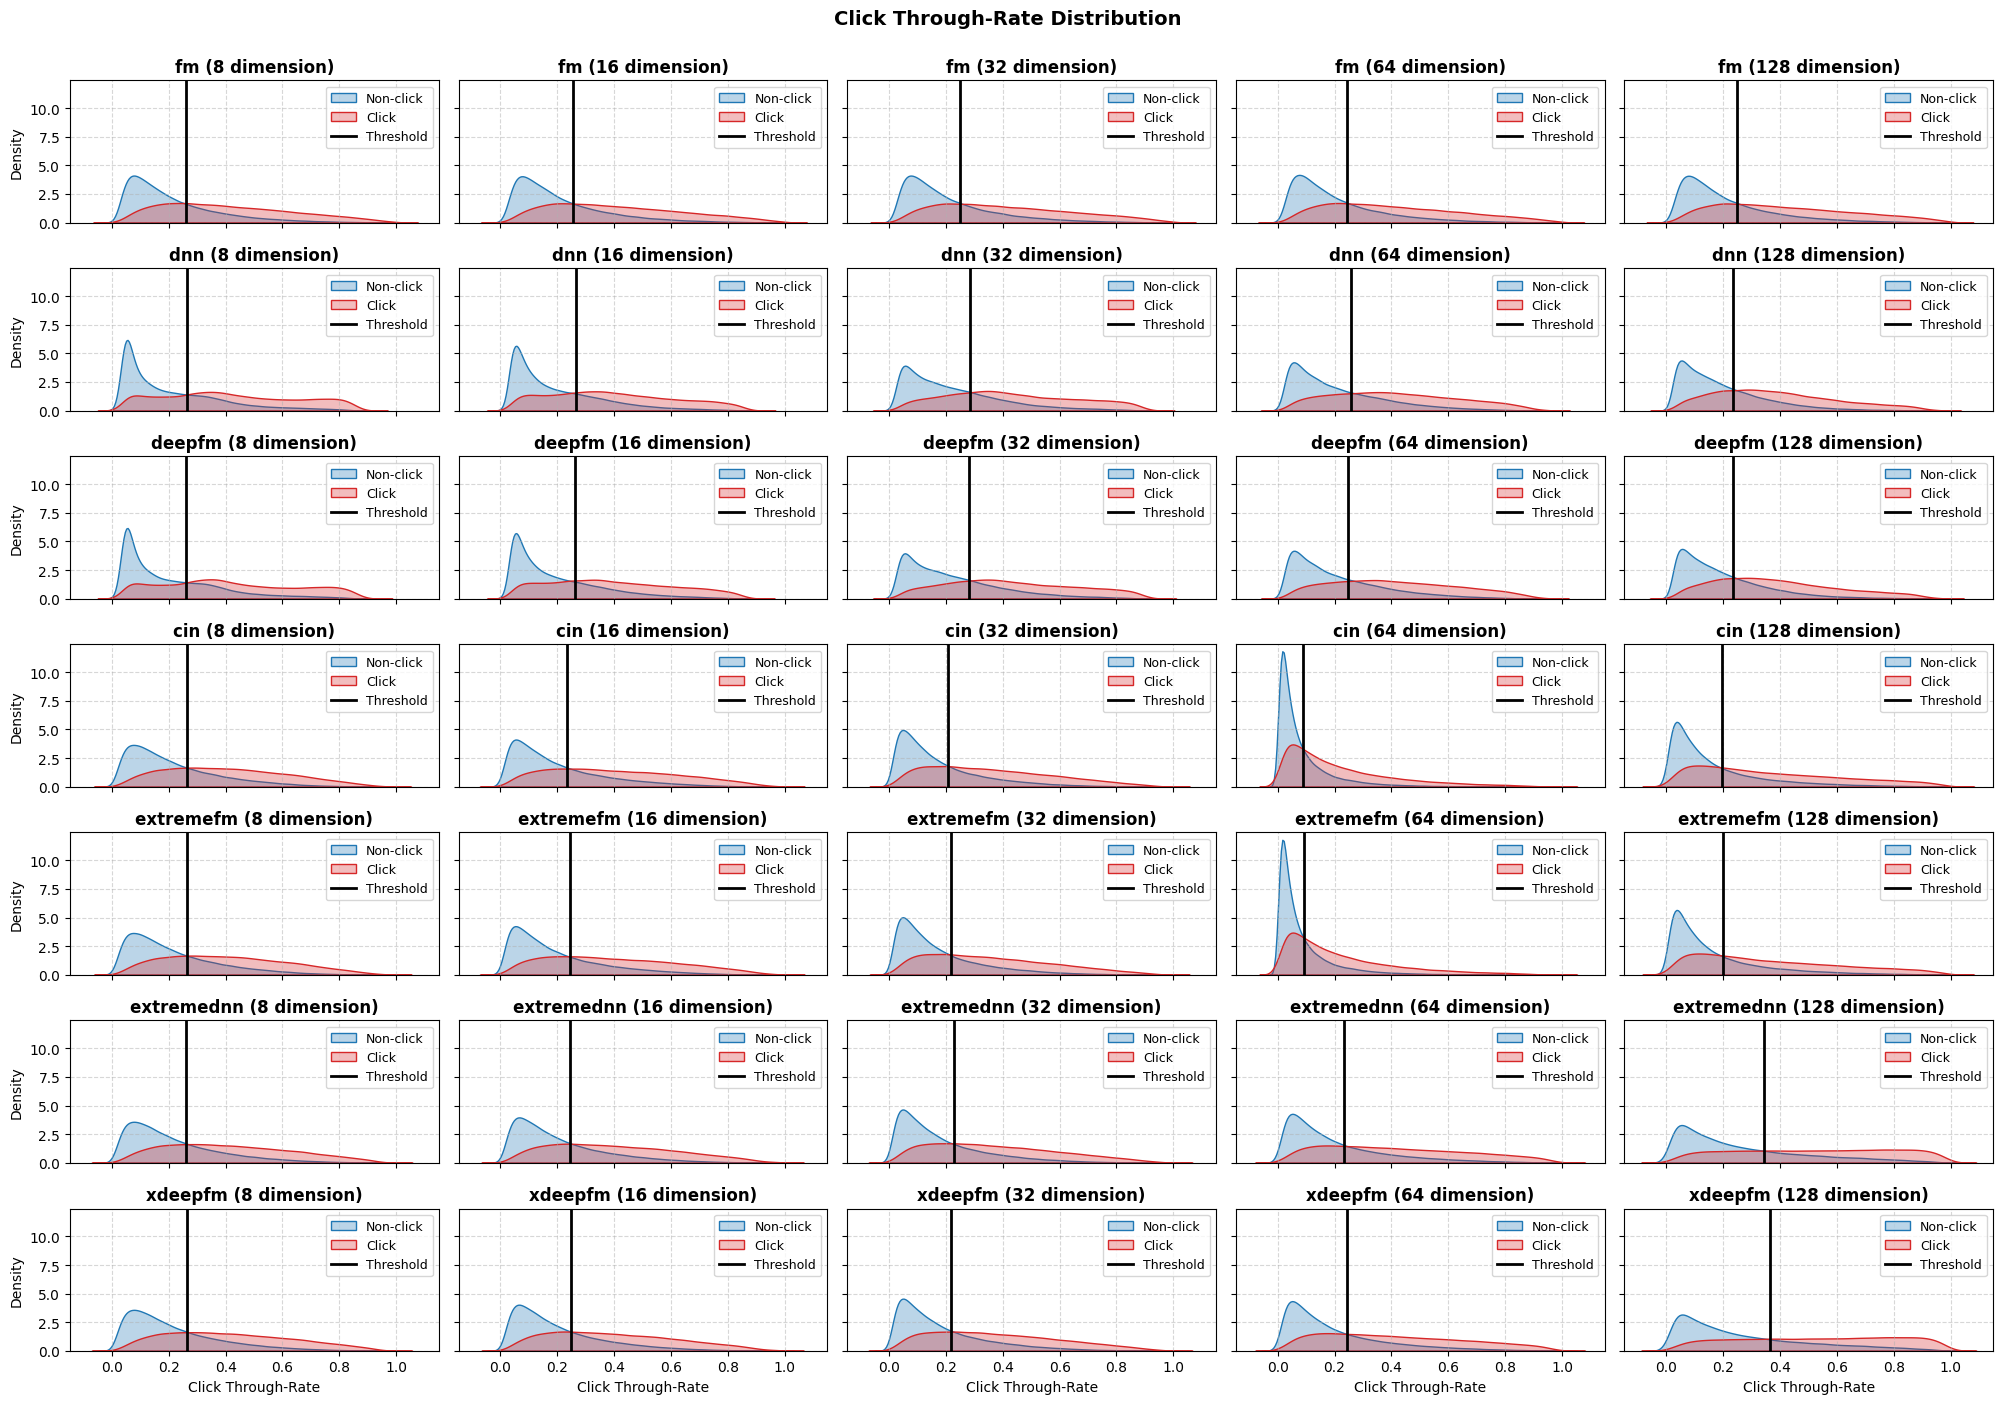

In [7]:
PATH = "./result/score"
FIGSIZE = (4,2)
MODELS = ["fm", "dnn", "deepfm", "cin", "extremefm", "extremednn", "xdeepfm"]
DIMS = [8, 16, 32, 64, 128]

kwargs = dict(
    path=PATH, 
    thresholds=thresholds, 
    figsize=FIGSIZE,
    models=MODELS,
    dims=DIMS,
)

analysis.distribution.main(**kwargs)

# Distribution (Versus)

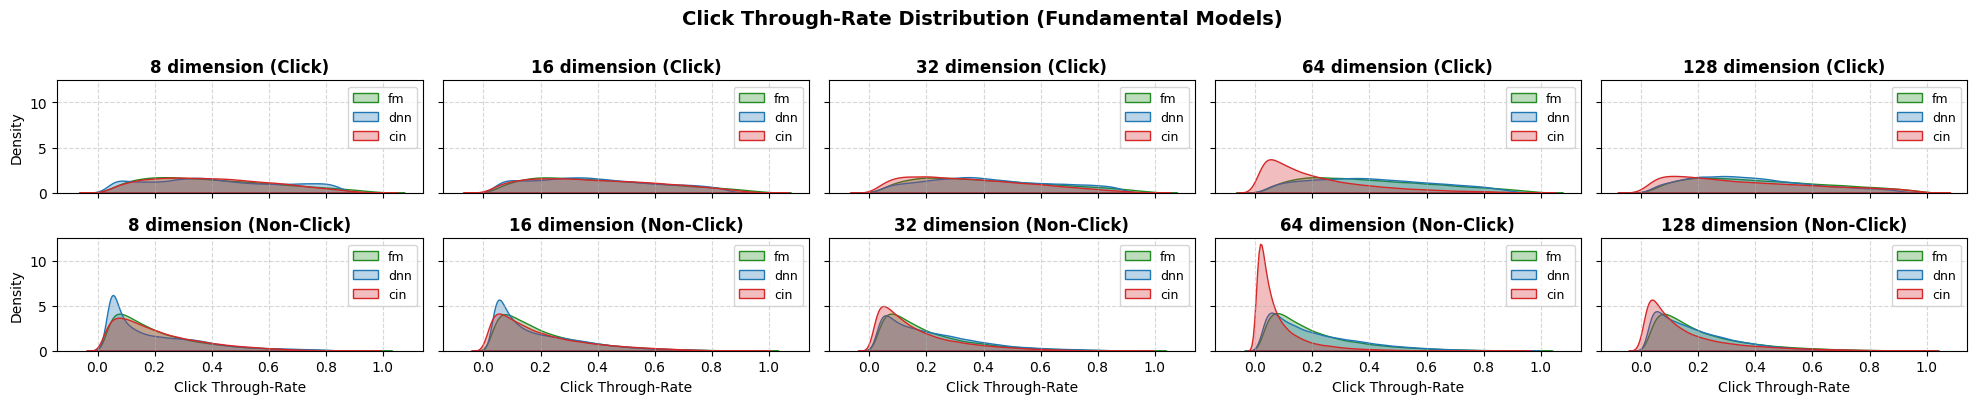

In [8]:
PATH = "./result/score"
FIGSIZE = (4,2)
MODELS = ["fm", "dnn", "cin"]
DIMS = [8, 16, 32, 64, 128]
SUPTITLE = "Fundamental Models"

kwargs = dict(
    path=PATH, 
    figsize=FIGSIZE, 
    models=MODELS, 
    dims=DIMS,
    suptitle=SUPTITLE,
)

analysis.versus.main(**kwargs)

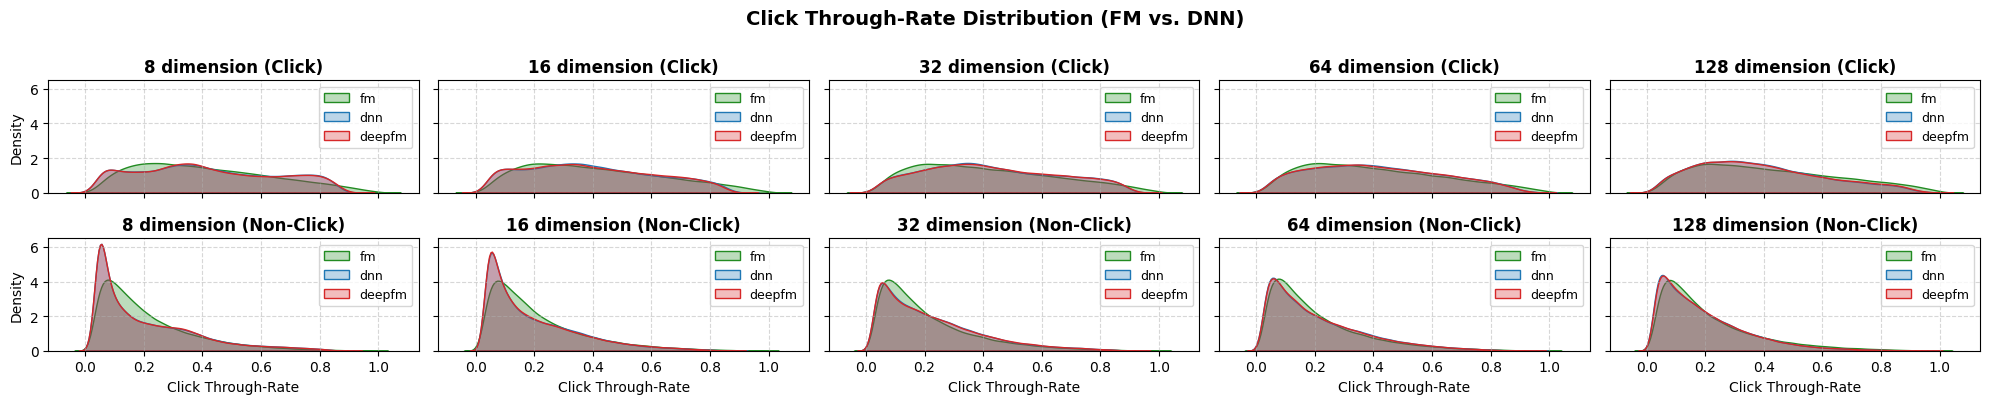

In [9]:
PATH = "./result/score"
FIGSIZE = (4,2)
MODELS = ["fm", "dnn", "deepfm"]
DIMS = [8, 16, 32, 64, 128]
SUPTITLE = "FM vs. DNN"

kwargs = dict(
    path=PATH, 
    figsize=FIGSIZE, 
    models=MODELS, 
    dims=DIMS,
    suptitle=SUPTITLE,
)

analysis.versus.main(**kwargs)

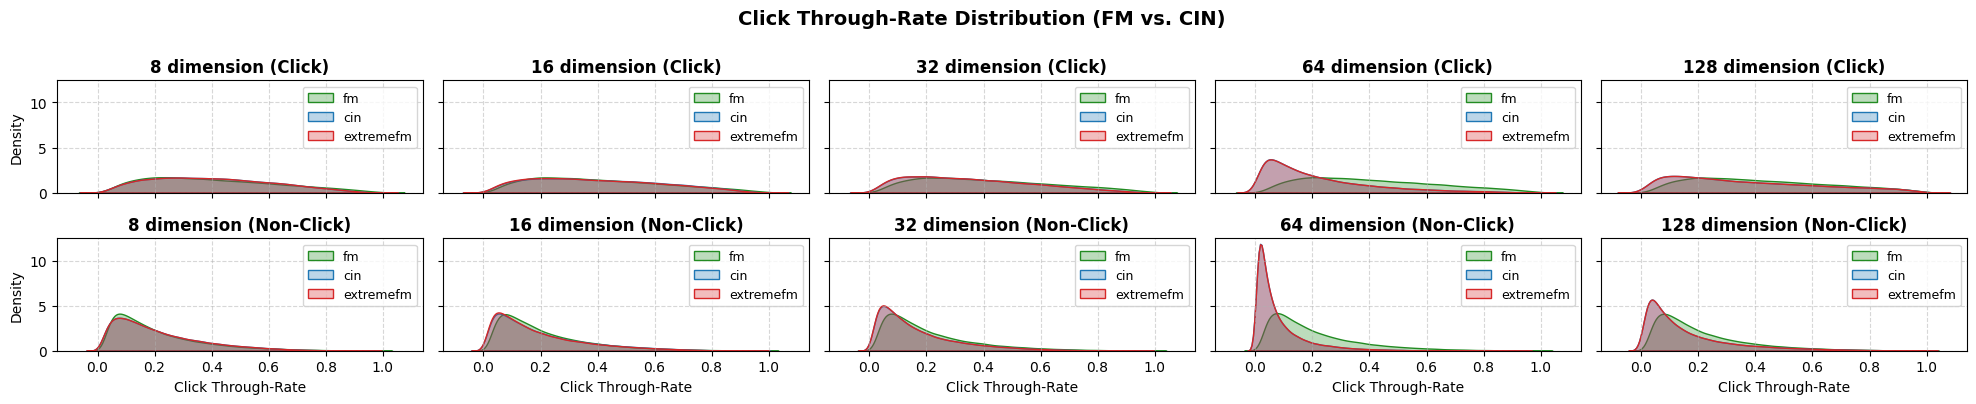

In [10]:
PATH = "./result/score"
FIGSIZE = (4,2)
MODELS = ["fm", "cin", "extremefm"]
DIMS = [8, 16, 32, 64, 128]
SUPTITLE = "FM vs. CIN"

kwargs = dict(
    path=PATH, 
    figsize=FIGSIZE, 
    models=MODELS, 
    dims=DIMS,
    suptitle=SUPTITLE,
)

analysis.versus.main(**kwargs)

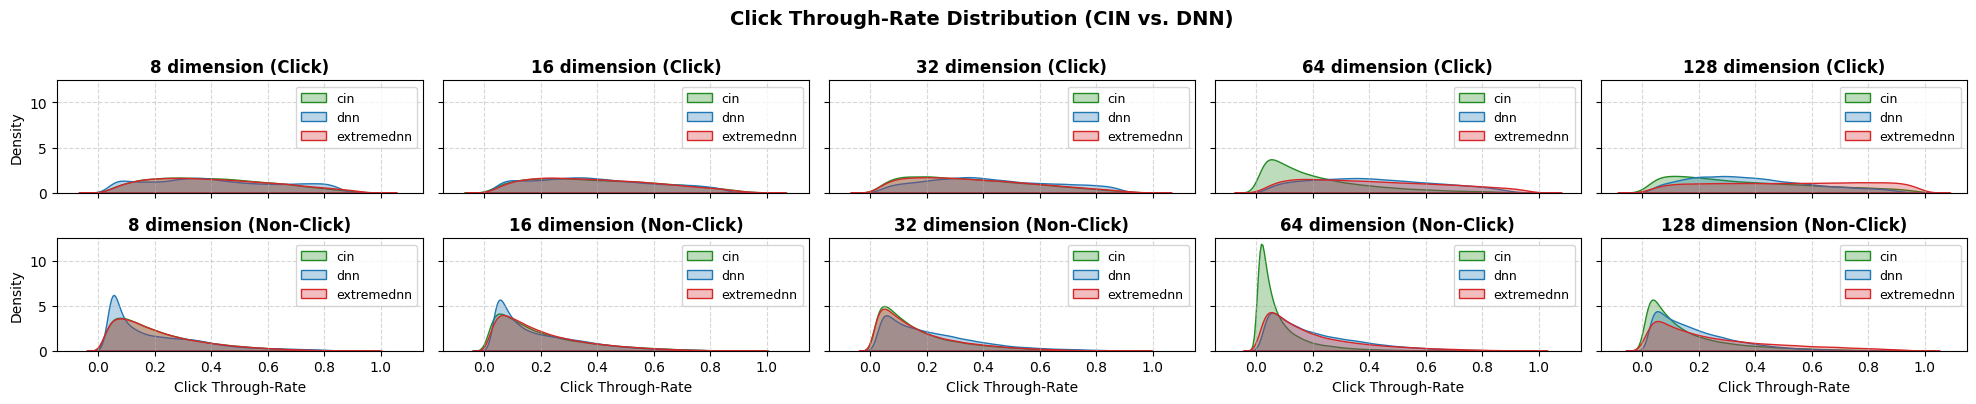

In [11]:
PATH = "./result/score"
FIGSIZE = (4,2)
MODELS = ["cin", "dnn", "extremednn"]
DIMS = [8, 16, 32, 64, 128]
SUPTITLE = "CIN vs. DNN"

kwargs = dict(
    path=PATH, 
    figsize=FIGSIZE, 
    models=MODELS, 
    dims=DIMS,
    suptitle=SUPTITLE,
)

analysis.versus.main(**kwargs)

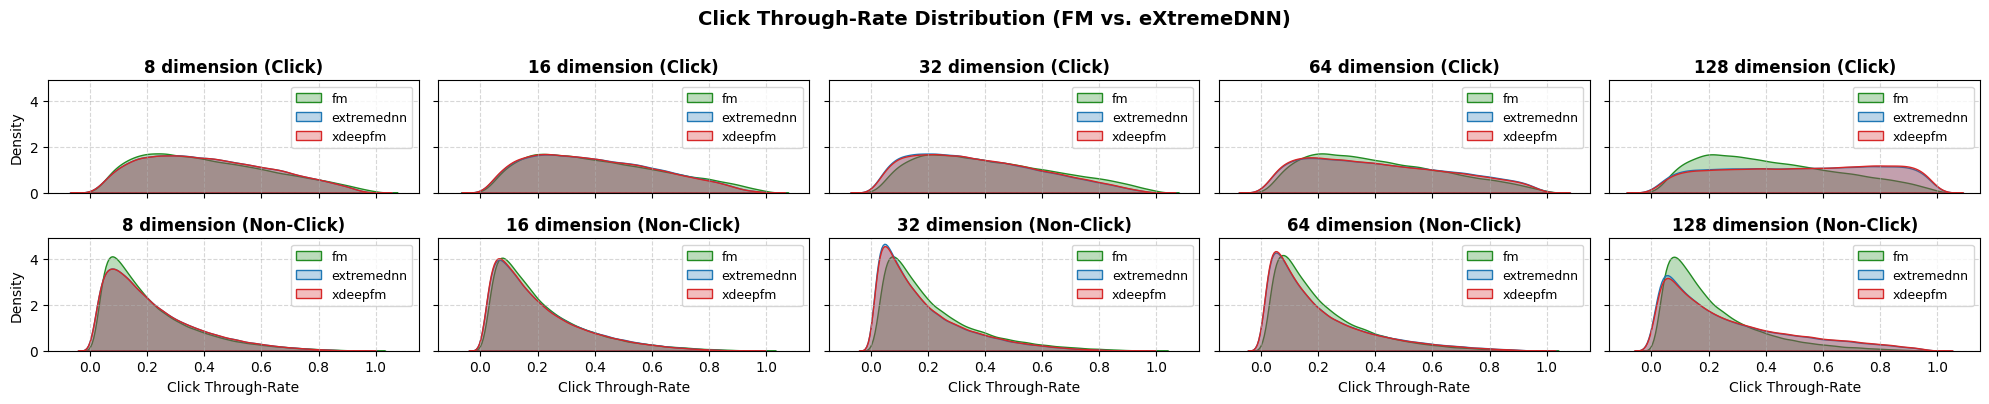

In [12]:
PATH = "./result/score"
FIGSIZE = (4,2)
MODELS = ["fm", "extremednn", "xdeepfm"]
DIMS = [8, 16, 32, 64, 128]
SUPTITLE = "FM vs. eXtremeDNN"

kwargs = dict(
    path=PATH, 
    figsize=FIGSIZE, 
    models=MODELS, 
    dims=DIMS,
    suptitle=SUPTITLE,
)

analysis.versus.main(**kwargs)

# Reliability Diagram

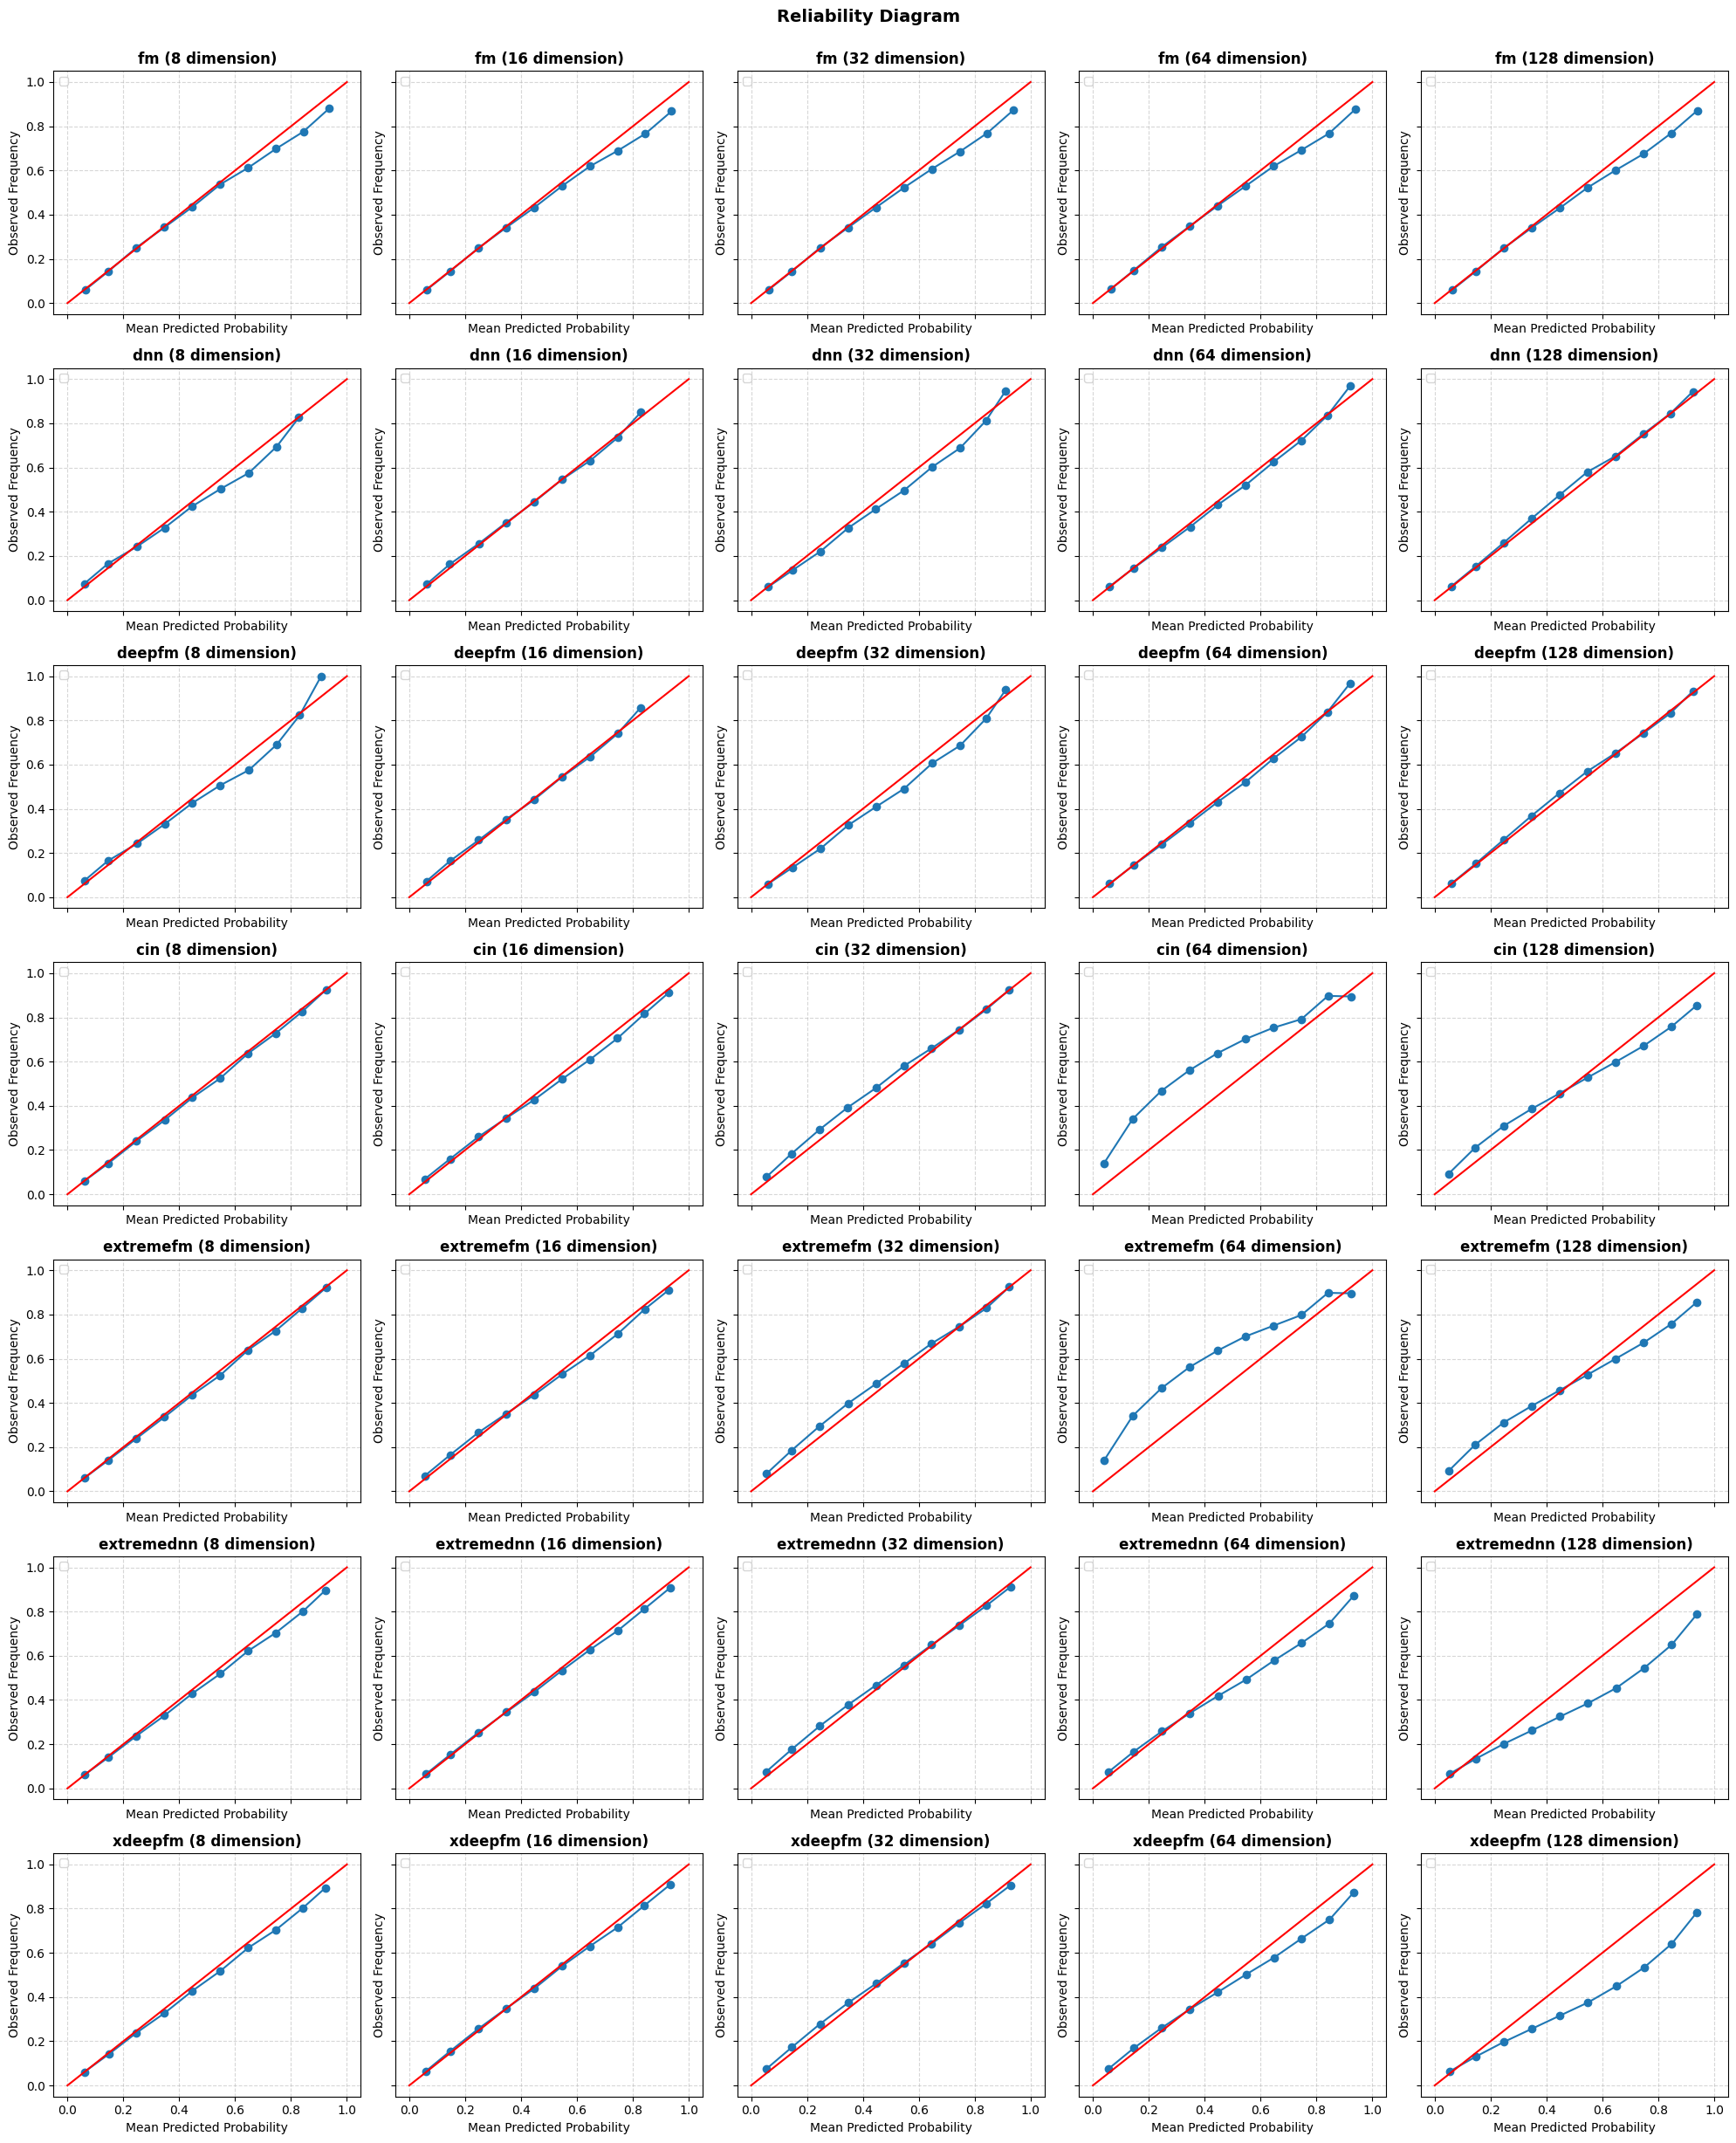

In [13]:
PATH = "./result/score"
Y_PROB = "prob"
Y_TRUE = "true"
FIGSIZE = (4,3.5)
MODELS = ["fm", "dnn", "deepfm", "cin", "extremefm", "extremednn", "xdeepfm"]
DIMS = [8, 16, 32, 64, 128]

kwargs = dict(
    path=PATH, 
    y_prob=Y_PROB,
    y_true=Y_TRUE,
    figsize=FIGSIZE, 
    models=MODELS, 
    dims=DIMS,
)

analysis.calibration.main(**kwargs)

# Metric

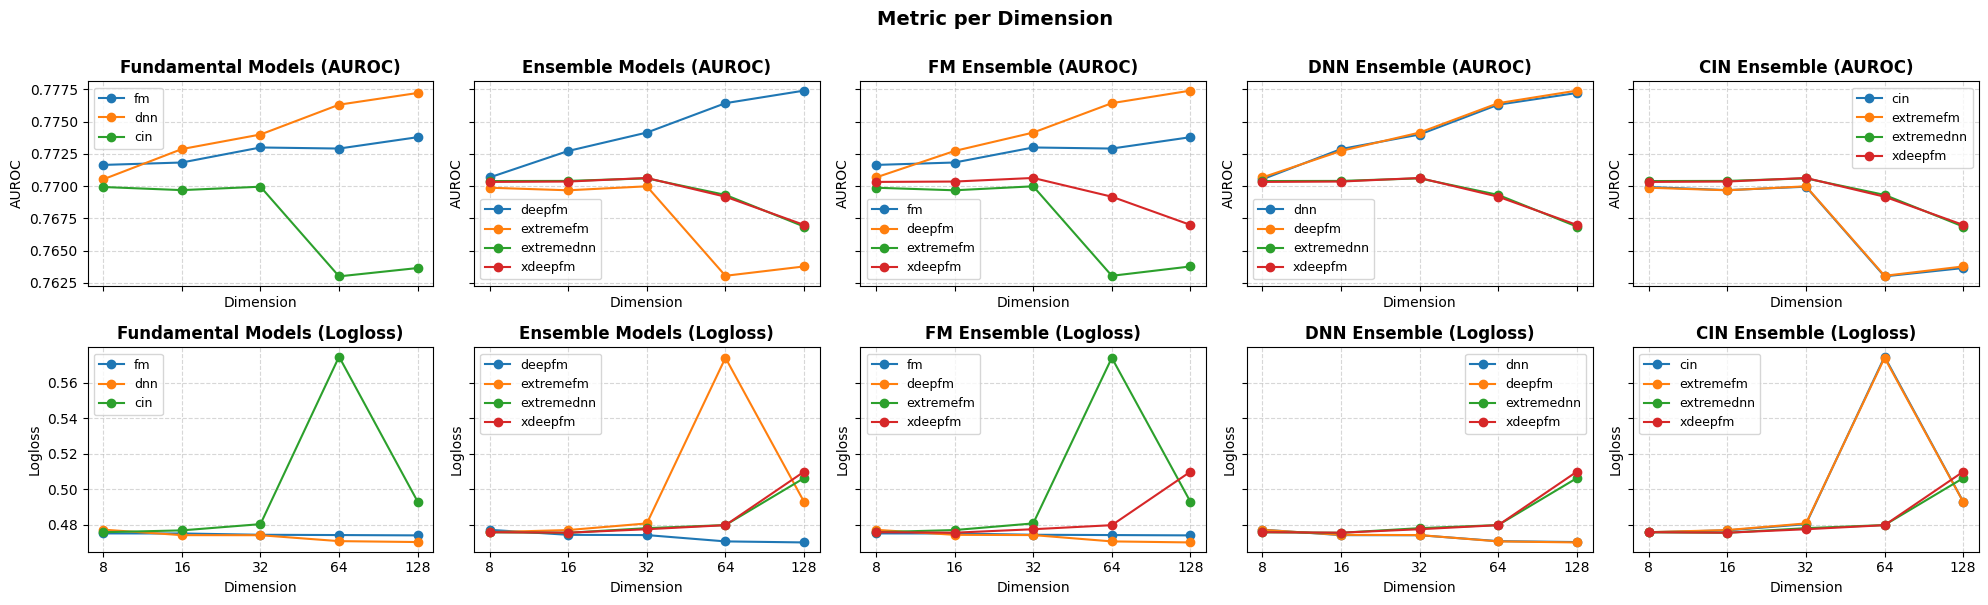

In [6]:
PATH = "./result/metric"
FIGSIZE = (4,3)
MODELSET = [
    ["fm", "dnn", "cin"], 
    ["deepfm", "extremefm", "extremednn", "xdeepfm"], 
    ["fm", "deepfm", "extremefm", "xdeepfm"],
    ["dnn", "deepfm", "extremednn", "xdeepfm"],
    ["cin", "extremefm", "extremednn", "xdeepfm"],
]
TITLES = [
    "Fundamental Models",
    "Ensemble Models",
    "FM Ensemble",
    "DNN Ensemble",
    "CIN Ensemble",
]

kwargs = dict(
    path=PATH,
    figsize=FIGSIZE,
    modelset=MODELSET,
    titles=TITLES,
)

analysis.metric.main(**kwargs)